In [28]:
from __future__ import annotations

from operator import add
from datetime import datetime
from enum import Enum
from typing import TypedDict, Annotated, Literal
from uuid import uuid4

from pydantic import BaseModel, Field, ValidationError, RootModel
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.checkpoint.memory import InMemorySaver
import os
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_core.output_parsers import PydanticOutputParser

import psycopg
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver
from dotenv import load_dotenv
import json

load_dotenv()

True

In [29]:

def get_database_url():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError(
            "DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env"
        )

    if "sslmode=" not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url = f"{database_url}{separator}sslmode=require"

    return database_url

In [30]:
GROK_API_KEY = os.getenv("GROK_API_KEY")
if not GROK_API_KEY:
    raise ValueError("GROK_API_KEY is missing. Please add it to your .env file.")

In [31]:

class RouteDecision(BaseModel):
    """Decision returned by the router."""

    route: Literal[
        "resource_research",
        "unsupported",
    ] = Field(
        description="The workflow that should handle the user's request."
    )


class Subtopic(BaseModel):
    """A subtopic identified from the user's main topic."""

    name: str = Field(
        description="Name of the subtopic."
    )

    description: str = Field(
        description="Short description of what the subtopic covers."
    )

    learning_order: int = Field(
        description="Recommended order in which the subtopic should be learned.",
        ge=1,
    )


class SearchTask(BaseModel):
    """A research task created by the orchestrator."""

    task_id: str = Field(
        description="Unique identifier for the search task."
    )

    category: str = Field(
        description=(
            "Type of resource to search for, such as "
            "documentation, GitHub, article, blog, book, course, or project."
        )
    )

    subtopic: str = Field(
        description="The subtopic that this task should investigate."
    )

    search_query: str = Field(
        description="The web search query that the worker should execute."
    )

class Resource(BaseModel):
    """A resource discovered and evaluated by a research worker."""

    title: str = Field(default="Untitled Resource")
    url: str = Field(default="")
    resource_type: str = Field(default="article")
    source: str = Field(default="Web")
    subtopic: str = Field(default="General")
    description: str = Field(default="")
    why_recommended: str = Field(default="")
    difficulty: str = Field(default="Intermediate")
    relevance_score: float = Field(default=5.0, ge=0, le=10)


class LearningStep(BaseModel):
    """A step in the recommended learning path."""

    order: int = Field(
        description="Order of this step in the learning path.",
        ge=1,
    )

    subtopic: str = Field(
        description="Subtopic to learn in this step."
    )

    resources: list[Resource] = Field(
        default_factory=list,
        description="Recommended resources for this learning step."
    )

class WorkerResources(RootModel[list[Resource]]):
    root: list[Resource]



In [32]:
class ResourceResearchState(TypedDict):

    user_query: str
    route: str
    topic: str
    subtopics: list[Subtopic]
    search_tasks: list[SearchTask]
    worker_results: Annotated[list[Resource], add]
    consolidated_resources: list[Resource]
    learning_path: list[LearningStep]
    final_report: str
    report_file: str

In [33]:
class WorkerState(TypedDict):
    task: SearchTask

In [34]:

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    api_key=GROK_API_KEY,
    temperature=0.2,
    max_tokens=4096,
    reasoning_format="hidden"
)


In [35]:
import re
import json

ROUTER_PROMPT = """Classify if the request is for researching learning resources.
Output ONLY JSON: {{"route": "resource_research" | "unsupported"}}

User: {query}"""

def router_node(state: ResourceResearchState) -> dict:
    response = llm.invoke(ROUTER_PROMPT.format(query=state["user_query"]))
    match = re.search(r'\{.*\}', response.content, re.DOTALL)
    route = "resource_research"
    if match:
        try:
            data = json.loads(match.group(0))
            route = data.get("route", "resource_research")
        except Exception:
            pass
    return {"route": route}

# ============================================================
# Conditional Routing
# ============================================================

def route_decision(
    state: ResourceResearchState,
) -> str:
    """
    Determine the next graph node based on the router decision.
    """

    if state["route"] == "resource_research":
        return "orchestrator"

    return "unsupported"

In [36]:
import re

def clean_topic_name(raw_topic: str, fallback_query: str = "") -> str:
    """
    Strips conversational and meta prefixes (e.g., 'learning resource guide for',
    'I want to learn', 'find resources on') to isolate the real technical subject.
    """
    text = (raw_topic or "").strip()
    if not text or text.lower() in ["resource guide", "learning guide", "resource_report", "technical guide"]:
        text = (fallback_query or "").strip()

    # Strip conversational and prompt boilerplate prefixes
    prefixes = [
        r"(?i)^(i\s+want\s+to\s+learn\s+(about\s+)?)",
        r"(?i)^(give\s+me\s+(the\s+best\s+)?(learning\s+)?resources?\s+(for|on|about|to\s+learn)\s+)",
        r"(?i)^(find\s+(the\s+best\s+)?(learning\s+)?resources?\s+(for|on|about|to\s+learn)\s+)",
        r"(?i)^(best\s+resources?\s+(for|on|about|to\s+learn)\s+)",
        r"(?i)^(learning\s+(resource\s+)?(guide|path|resources?)\s+(for|on|about|to)\s+)",
        r"(?i)^(resource\s+(guide|path)\s+(for|on|about|to)\s+)",
        r"(?i)^(guide\s+(for|on|about|to)\s+)",
        r"(?i)^(tutorials?\s+(for|on|about|to)\s+)",
    ]
    for pattern in prefixes:
        text = re.sub(pattern, "", text).strip()

    # Final sanity fallback
    if not text or text.lower() in ["resource guide", "learning guide", "guide", "resources"]:
        text = fallback_query.strip() or "Core Technology"

    return text.title()

In [37]:
class OrchestratorOutput(BaseModel):
    """Structured research plan created by the orchestrator."""

    topic: str = Field(
        description="The main topic identified from the user's request."
    )

    subtopics: list[Subtopic] = Field(
        description="Ordered subtopics required to learn the main topic."
    )

    search_tasks: list[SearchTask] = Field(
        description="Search tasks that will be distributed to workers."
    )

In [38]:
ORCH_PROMPT = """Analyze the user request and extract the core subject matter.
Create a focused research plan.

Rules:
- "topic" MUST be the isolated subject name (e.g. "LLM Inference", "LangGraph", "RAG"), NEVER "Resource Guide" or "Learning Path".
- Max 3 key subtopics in logical learning order.
- Exactly 1 targeted search task per subtopic (max 3 total).

Return ONLY valid JSON matching this schema:
{{
  "topic": "Core Subject Name",
  "subtopics": [{{"name": "Subtopic Name", "description": "Short description", "learning_order": 1}}],
  "search_tasks": [{{"task_id": "t1", "category": "documentation|article|GitHub", "subtopic": "Subtopic Name", "search_query": "specific search query"}}]
}}

User Request: {query}"""

def orchestrator_node(state: ResourceResearchState) -> dict:
    response = llm.invoke(ORCH_PROMPT.format(query=state["user_query"]))
    match = re.search(r'\{.*\}', response.content, re.DOTALL)
    
    clean_topic = clean_topic_name(state.get("topic", ""), state["user_query"])

    if match:
        try:
            data = json.loads(match.group(0))
            raw_extracted_topic = data.get("topic", "")
            final_topic = clean_topic_name(raw_extracted_topic, state["user_query"])
            
            subtopics = [Subtopic.model_validate(s) for s in data.get("subtopics", [])[:3]]
            tasks = [SearchTask.model_validate(t) for t in data.get("search_tasks", [])[:3]]
            
            return {
                "topic": final_topic,
                "subtopics": subtopics,
                "search_tasks": tasks,
            }
        except Exception:
            pass

    # Safe fallback
    return {
        "topic": clean_topic,
        "subtopics": [Subtopic(name="Foundations", description=f"Core concepts of {clean_topic}", learning_order=1)],
        "search_tasks": [SearchTask(task_id="t1", category="documentation", subtopic="Foundations", search_query=f"{clean_topic} official documentation tutorial")]
    }

In [39]:
import json
import re

search_tool = TavilySearch(max_results=3)

# ============================================================
# Safe JSON Extraction Helper
# ============================================================

def extract_json_array(text: str) -> list[dict]:
    """
    Robustly extracts JSON list of dictionaries from LLM output,
    handling markdown blocks, extra text, and malformed strings.
    """
    text = text.strip()

    # 1. Try extracting from markdown code fences first
    if "```" in text:
        code_blocks = re.findall(r"```(?:json)?\s*([\s\S]*?)\s*```", text)
        for block in code_blocks:
            try:
                data = json.loads(block.strip())
                if isinstance(data, list):
                    return data
                if isinstance(data, dict):
                    return [data]
            except json.JSONDecodeError:
                pass

    # 2. Try finding the first clean array [...]
    start = text.find('[')
    end = text.rfind(']')
    if start != -1 and end != -1 and end > start:
        array_str = text[start:end + 1]
        try:
            data = json.loads(array_str)
            if isinstance(data, list):
                return data
        except json.JSONDecodeError:
            pass

    # 3. Fallback: Parse individual {...} objects
    items = []
    # Match non-nested JSON objects
    object_matches = re.findall(r'\{[^{}]*\}', text)
    for obj_str in object_matches:
        try:
            obj = json.loads(obj_str)
            if isinstance(obj, dict) and obj.get("url"):
                items.append(obj)
        except json.JSONDecodeError:
            continue

    return items

# ============================================================
# Worker Prompt & Node
# ============================================================

def sanitize_search_results(results: list[dict] | dict | str, max_items: int = 3) -> str:
    """Extracts only essential fields to prevent token overflow."""
    if isinstance(results, dict) and "results" in results:
        results = results["results"]
    if isinstance(results, list):
        clean = [
            {
                "title": item.get("title", ""),
                "url": item.get("url", ""),
                "snippet": (item.get("content") or item.get("snippet", ""))[:200]
            }
            for item in results[:max_items]
        ]
        return json.dumps(clean, separators=(',', ':'))
    return str(results)[:1500]

WORKER_PROMPT = """Evaluate search results for the subtopic. Extract up to 2 high-quality resources.
Return ONLY a valid JSON array:
[{{"title": "...", "url": "https://...", "resource_type": "...", "source": "...", "subtopic": "{subtopic}", "description": "1 concise sentence.", "why_recommended": "1 brief reason.", "difficulty": "Beginner|Intermediate|Advanced", "relevance_score": 8.5}}]

Search Data:
{search_context}"""

def worker_node(state: WorkerState) -> dict:
    task = state["task"]

    try:
        search_results = search_tool.invoke({"query": task.search_query})
    except Exception as exc:
        raise RuntimeError(f"Web search failed for {task.task_id}: {exc}") from exc

    if not search_results:
        return {"worker_results": []}

    search_context = sanitize_search_results(search_results, max_items=3)

    try:
        response = llm.invoke(
            WORKER_PROMPT.format(
                subtopic=task.subtopic,
                search_context=search_context
            )
        )
        
        parsed_items = extract_json_array(response.content)
        valid_resources: list[Resource] = []

        for item in parsed_items:
            if isinstance(item, dict) and item.get("url"):
                item.setdefault("subtopic", task.subtopic)
                try:
                    valid_resources.append(Resource.model_validate(item))
                except Exception:
                    continue

        return {"worker_results": valid_resources}

    except Exception as exc:
        # Return empty list rather than breaking the entire multi-worker graph
        return {"worker_results": []}

In [40]:
def worker_fanout(
    state: ResourceResearchState,
) -> list[Send]:
    """
    Create one worker execution for each search task
    generated by the orchestrator.
    """

    search_tasks = state.get("search_tasks", [])

    # --------------------------------------------------------
    # Edge case: no search tasks
    # --------------------------------------------------------

    if not search_tasks:
        return []

    # --------------------------------------------------------
    # Create one worker branch per search task
    # --------------------------------------------------------

    return [
        Send(
            "worker",
            {
                "task": task,
            },
        )
        for task in search_tasks
    ]

In [41]:

def reducer_node(
    state: ResourceResearchState,
) -> dict:
    """
    Consolidate results produced by all parallel workers.

    Responsibilities:
    - Remove duplicate resources.
    - Keep the most relevant resources.
    - Group resources by subtopic.
    - Build the recommended learning path.
    """

    worker_results = state.get(
        "worker_results",
        [],
    )

    subtopics = state.get(
        "subtopics",
        [],
    )

    # ========================================================
    # Edge Case: No Worker Results
    # ========================================================

    if not worker_results:
        return {
            "consolidated_resources": [],
            "learning_path": [],
        }

    # ========================================================
    # 1. Remove Duplicate Resources
    # ========================================================

    unique_resources: dict[str, Resource] = {}

    for resource in worker_results:

        # URL is the primary identifier for a resource.
        key = resource.url.strip().lower()

        if not key:
            continue

        # If the same URL was found by multiple workers,
        # keep the resource with the higher relevance score.
        if key not in unique_resources:
            unique_resources[key] = resource

        elif (
            resource.relevance_score
            > unique_resources[key].relevance_score
        ):
            unique_resources[key] = resource

    deduplicated_resources = list(
        unique_resources.values()
    )

    # ========================================================
    # 2. Rank Resources
    # ========================================================

    consolidated_resources = sorted(
        deduplicated_resources,
        key=lambda resource: resource.relevance_score,
        reverse=True,
    )

    # ========================================================
    # 3. Group Resources by Subtopic
    # ========================================================

    resources_by_subtopic: dict[str, list[Resource]] = {}

    for resource in consolidated_resources:

        subtopic_key = resource.subtopic.strip().lower()

        resources_by_subtopic.setdefault(
            subtopic_key,
            [],
        ).append(resource)

    # ========================================================
    # 4. Create Learning Path
    # ========================================================

    learning_path: list[LearningStep] = []

    # Subtopics already contain learning_order.
    ordered_subtopics = sorted(
        subtopics,
        key=lambda subtopic: subtopic.learning_order,
    )

    for subtopic in ordered_subtopics:

        subtopic_key = subtopic.name.strip().lower()

        resources = resources_by_subtopic.get(
            subtopic_key,
            [],
        )

        # Keep resources ranked by relevance.
        resources = sorted(
            resources,
            key=lambda resource: resource.relevance_score,
            reverse=True,
        )

        learning_path.append(
            LearningStep(
                order=subtopic.learning_order,
                subtopic=subtopic.name,
                resources=resources,
            )
        )

    # ========================================================
    # 5. Return Updated State
    # ========================================================

    return {
        "consolidated_resources": consolidated_resources,
        "learning_path": learning_path,
    }

In [42]:
import re

# ============================================================
# Report Generator Prompt (Focused on Direct Markdown Output)
# ============================================================

REPORT_PROMPT = """You are a technical documentation specialist.
Generate a comprehensive, beautifully structured Markdown Learning Guide / README based ONLY on the provided resource data.

Topic: {topic}

Resources & Evidence:
{resource_summary}

Generate the report strictly following this Markdown structure:

# 📚 Learning Resource Guide: {topic}

> A curated collection of top-tier resources, documentation, and technical deep-dives to master **{topic}**.

---

## 📌 1. Topic Overview
[Provide a concise 2-3 sentence overview explaining what the topic is, why it matters, and the core challenge it solves.]

---

## 🗺️ 2. Recommended Learning Roadmap

| Phase | Focus Area | Recommended Action |
| :--- | :--- | :--- |
| **Phase 1: Foundations** | Core Architecture & Concepts | Understand definitions, fundamentals, and key performance metrics. |
| **Phase 2: Hands-on Practice** | Tutorials & Implementation | Follow step-by-step guides to build and run inference workflows. |
| **Phase 3: Optimization** | Production Best Practices | Fine-tune latency, throughput, and deployment efficiency. |

---

## 📑 3. Curated Resource Directory

| Resource Title | Format | Difficulty | Key Takeaway / Why Recommended |
| :--- | :--- | :--- | :--- |
[Populate rows directly from the provided resources with clickable markdown links]

---

## 🔍 4. Deep-Dive Details
[For each resource, provide bullet points with its clickable title, source platform, and practical description.]

---

## 💡 5. Next Steps & Practical Advice
- **Where to Start:** [1 clear starting recommendation]
- **Key Pitfalls to Avoid:** [1 practical caution when learning this topic]

---
*Report generated automatically by Tech-ResourcePlanner Agent AI.*
"""

def clean_model_output(text: str) -> str:
    """Removes thinking traces and extraneous formatting from the model output."""
    # Strip <think>...</think> blocks generated by reasoning models
    cleaned = re.sub(r"<think>[\s\S]*?</think>", "", text, flags=re.DOTALL).strip()
    return cleaned

def report_generator_node(state: ResourceResearchState) -> dict:
    """
    Generate a polished Markdown report with a validated topic name.
    """
    clean_topic = clean_topic_name(state.get("topic", ""), state.get("user_query", ""))
    resources = state.get("consolidated_resources", [])

    if not resources:
        empty_report = (
            f"# 📚 Learning Resource Guide: {clean_topic}\n\n"
            f"> No verified technical resources were discovered for this topic.\n"
        )
        return {
            "topic": clean_topic,
            "final_report": empty_report
        }

    summary_lines = []
    for idx, r in enumerate(resources[:8], start=1):
        summary_lines.append(
            f"{idx}. Title: {r.title}\n"
            f"   URL: {r.url}\n"
            f"   Type: {r.resource_type} | Source: {r.source} | Subtopic: {r.subtopic}\n"
            f"   Difficulty: {r.difficulty} | Score: {r.relevance_score}/10\n"
            f"   Description: {r.description}\n"
            f"   Why Recommended: {r.why_recommended}\n"
        )

    resource_summary = "\n".join(summary_lines)

    report_llm = llm.bind(max_tokens=4096)
    response = report_llm.invoke(
        REPORT_PROMPT.format(
            topic=clean_topic,
            resource_summary=resource_summary
        )
    )

    final_markdown = clean_model_output(response.content)

    return {
        "topic": clean_topic,
        "final_report": final_markdown
    }


In [43]:
from pathlib import Path
import re




# ============================================================
# Filename Helper
# ============================================================

def create_report_filename(topic: str) -> str:
    """
    Convert the topic into a safe Markdown filename.
    """

    filename = topic.strip().lower()

    filename = re.sub(
        r"[^a-z0-9]+",
        "_",
        filename,
    )

    filename = filename.strip("_")

    return f"{filename}_learning_resources.md"


# ============================================================
# Markdown File Generator Node
# ============================================================

def markdown_file_node(state: ResourceResearchState) -> dict:
    topic = clean_topic_name(state.get("topic", ""), state.get("user_query", "tech_guide"))
    final_report = state.get("final_report", "").strip()

    if not final_report:
        raise ValueError("Cannot create Markdown file because final_report is empty.")

    output_dir = Path("reports")
    output_dir.mkdir(parents=True, exist_ok=True)

    filename = create_report_filename(topic)
    file_path = output_dir / filename

    file_path.write_text(final_report, encoding="utf-8")

    return {
        "report_file": str(file_path)
    }

In [44]:


# ============================================================
# Graph Builder
# ============================================================

builder = StateGraph(
    ResourceResearchState
)


# ============================================================
# Add Nodes
# ============================================================

builder.add_node(
    "router",
    router_node,
)

builder.add_node(
    "orchestrator",
    orchestrator_node,
)

builder.add_node(
    "worker",
    worker_node,
)

builder.add_node(
    "reducer",
    reducer_node,
)

builder.add_node(
    "report_generator",
    report_generator_node,
)

builder.add_node(
    "markdown_file",
    markdown_file_node,
)


# ============================================================
# START → Router
# ============================================================

builder.add_edge(
    START,
    "router",
)


# ============================================================
# Router → Orchestrator / END
# ============================================================

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "orchestrator": "orchestrator",
        "unsupported": END,
    },
)


# ============================================================
# Orchestrator → Dynamic Worker Fan-out
# ============================================================

builder.add_conditional_edges(
    "orchestrator",
    worker_fanout,
    {
        "worker": "worker",
    },
)


# ============================================================
# Worker → Reducer
# ============================================================

builder.add_edge(
    "worker",
    "reducer",
)


# ============================================================
# Reducer → Report Generator
# ============================================================

builder.add_edge(
    "reducer",
    "report_generator",
)


# ============================================================
# Report Generator → Markdown File
# ============================================================

builder.add_edge(
    "report_generator",
    "markdown_file",
)


# ============================================================
# Markdown File → END
# ============================================================

builder.add_edge(
    "markdown_file",
    END,
)


In [45]:
# =========================
# PostgreSQL Checkpointer
# =========================
DATABASE_URL = get_database_url()

_conn = psycopg.connect(
    DATABASE_URL,
    autocommit=True,
    row_factory=dict_row
)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()

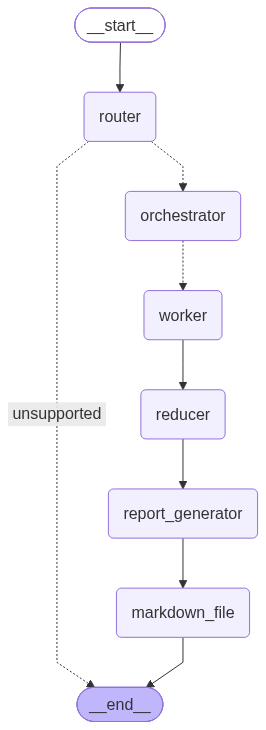

In [46]:

graph = builder.compile(
    checkpointer=checkpointer,
)
graph

In [47]:
import uuid



# ============================================================
# User Input
# ============================================================

user_query = input(
    "\nWhat topic would you like to research?\n> "
).strip()


# ============================================================
# Basic Input Validation
# ============================================================

if not user_query:
    raise ValueError(
        "User query cannot be empty."
    )


# ============================================================
# Initial State
# ============================================================

initial_state = {
    "user_query": user_query,

    # Router
    "route": "",

    # Orchestrator
    "topic": "",
    "subtopics": [],
    "search_tasks": [],

    # Workers
    "worker_results": [],

    # Reducer
    "consolidated_resources": [],
    "learning_path": [],

    # Report
    "final_report": "",
    "report_file": "",
}


# ============================================================
# Thread Configuration
# ============================================================

thread_id = str(
    uuid.uuid4()
)

config = {
    "configurable": {
        "thread_id": thread_id
    }
}


# ============================================================
# Run Graph
# ============================================================

result = graph.invoke(
    initial_state,
    config=config,
)


# ============================================================
# Handle Unsupported Request
# ============================================================

if result.get("route") == "unsupported":

    print(
        "\nThis request is outside the scope of the "
        "Resource Consolidation Agent."
    )

    print(
        "Please provide a topic for which you want "
        "learning resources."
    )


# ============================================================
# Handle Successful Research
# ============================================================

elif result.get("report_file"):

    print(
        "\n=============================================="
    )

    print(
        "Resource research completed successfully."
    )

    print(
        "=============================================="
    )

    print(
        f"\nTopic: {result.get('topic', user_query)}"
    )

    print(
        f"Report file: {result['report_file']}"
    )

    print(
        f"Thread ID: {thread_id}"
    )


# ============================================================
# Unexpected Graph Completion
# ============================================================

else:

    print(
        "\nThe graph completed, but no report file "
        "was generated."
    )

    print(
        f"Thread ID: {thread_id}"
    )


Resource research completed successfully.

Topic: Llm Inference
Report file: reports/llm_inference_learning_resources.md
Thread ID: ff8e6c21-f08a-461f-92ab-47737f46f93b
